INTRODUCTION
This dataset is designed to predict diseases based on a combination of environmental conditions (like temperature, humidity, and wind speed) and human symptoms (like cough, fever, nausea, etc.). Each row represents a patient record, with the final diagnosis labeled under the prognosis column.

Total Records: 4,981

Total Features: 51

Numerical features: Age, Temperature (C), Humidity, Wind Speed (km/h)

Binary symptom indicators (e.g., nausea, cough, etc.)

Target: prognosis (disease name)



IMPORTING LIBRARIES

In [35]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

LOAD THE DATASET

In [36]:
df=pd.read_csv(r'C:\smeclabs\DataScience\Projects\data_analysis\Weather-related disease prediction.csv')
df.head()

,Age,Gender,Temperature (C),Humidity,Wind Speed (km/h),nausea,joint_pain,abdominal_pain,high_fever,chills,...,facial_pain,shortness_of_breath,reduced_smell_and_taste,skin_irritation,itchiness,throbbing_headache,confusion,back_pain,knee_ache,prognosis
0,4,1,25.826,0.740000,8.289000,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Heart Attack
1,55,0,21.628,0.600000,15.236000,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,Influenza
2,45,0,13.800,0.817083,4.291992,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Influenza
3,6,0,37.254,0.610000,18.009000,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Dengue
4,70,0,18.162,0.870000,17.916000,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Sinusitis


CHWCKING NULL VALUES

In [37]:
df.isnull().sum()

Age                        0
Gender                     0
Temperature (C)            0
Humidity                   0
Wind Speed (km/h)          0
nausea                     0
joint_pain                 0
abdominal_pain             0
high_fever                 0
chills                     0
fatigue                    0
runny_nose                 0
pain_behind_the_eyes       0
dizziness                  0
headache                   0
chest_pain                 0
vomiting                   0
cough                      0
shivering                  0
asthma_history             0
high_cholesterol           0
diabetes                   0
obesity                    0
hiv_aids                   0
nasal_polyps               0
asthma                     0
high_blood_pressure        0
severe_headache            0
weakness                   0
trouble_seeing             0
fever                      0
body_aches                 0
sore_throat                0
sneezing                   0
diarrhea      

In [38]:
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Data types:\n", df.dtypes)



Shape: (5200, 51)
Missing values:
 Age                        0
Gender                     0
Temperature (C)            0
Humidity                   0
Wind Speed (km/h)          0
nausea                     0
joint_pain                 0
abdominal_pain             0
high_fever                 0
chills                     0
fatigue                    0
runny_nose                 0
pain_behind_the_eyes       0
dizziness                  0
headache                   0
chest_pain                 0
vomiting                   0
cough                      0
shivering                  0
asthma_history             0
high_cholesterol           0
diabetes                   0
obesity                    0
hiv_aids                   0
nasal_polyps               0
asthma                     0
high_blood_pressure        0
severe_headache            0
weakness                   0
trouble_seeing             0
fever                      0
body_aches                 0
sore_throat                0
sneezing

CHECKING DUPLICATES

In [39]:
df.duplicated()
df.duplicated().sum()

219

In [40]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4981 entries, 0 to 5199
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4981 non-null   int64  
 1   Gender                   4981 non-null   int64  
 2   Temperature (C)          4981 non-null   float64
 3   Humidity                 4981 non-null   float64
 4   Wind Speed (km/h)        4981 non-null   float64
 5   nausea                   4981 non-null   int64  
 6   joint_pain               4981 non-null   int64  
 7   abdominal_pain           4981 non-null   int64  
 8   high_fever               4981 non-null   int64  
 9   chills                   4981 non-null   int64  
 10  fatigue                  4981 non-null   int64  
 11  runny_nose               4981 non-null   int64  
 12  pain_behind_the_eyes     4981 non-null   int64  
 13  dizziness                4981 non-null   int64  
 14  headache                 4981

In [42]:
missing_values = df.isnull().sum()

missing_columns = missing_values[missing_values > 0]
print("Columns with missing values:\n", missing_columns)


Columns with missing values:
 Series([], dtype: int64)


MANIPULATING THE DATASET

1. What is the distribution of diseases (prognosis) in the dataset?

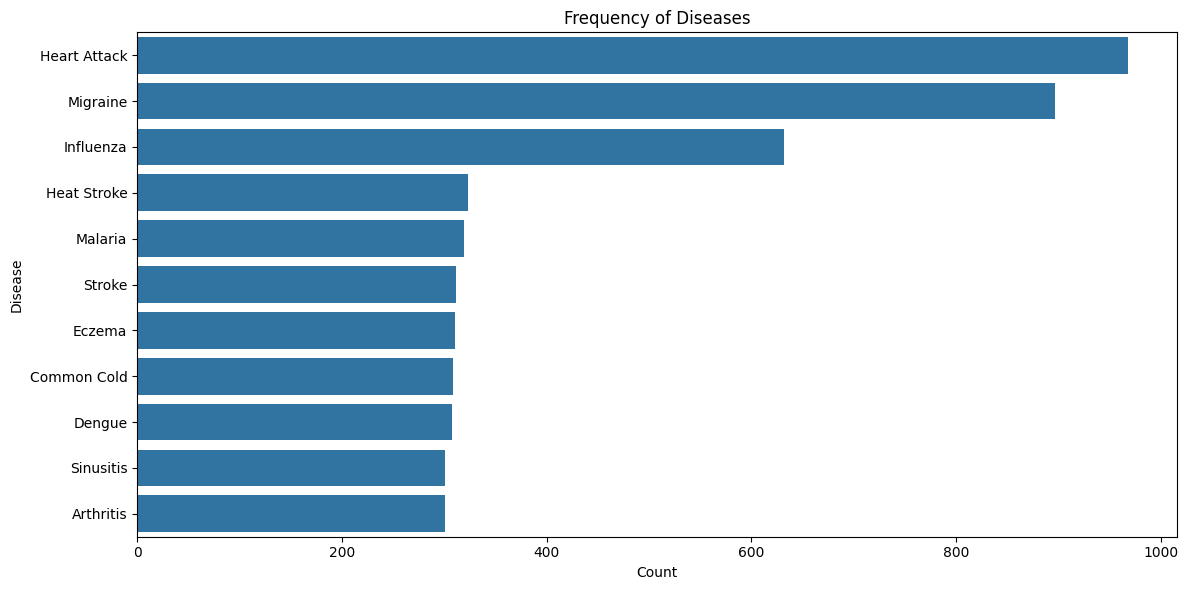

In [43]:

plt.figure(figsize=(12, 6))
sns.countplot(y='prognosis', data=df, order=df['prognosis'].value_counts().index)
plt.title('Frequency of Diseases')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()


2. Is there a gender imbalance in the dataset?

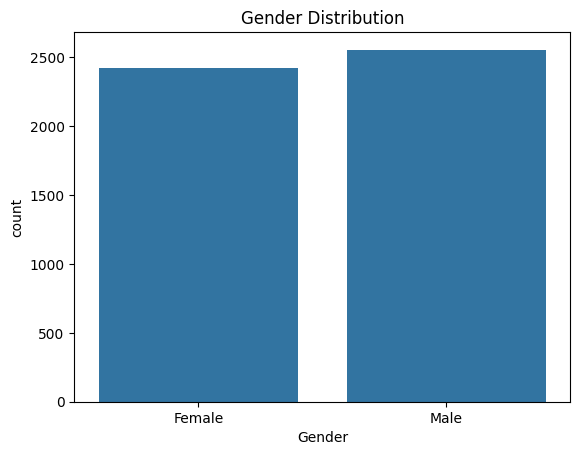

In [44]:
sns.countplot(x='Gender', data=df)
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Gender Distribution')
plt.show()


3. What is the age distribution of patients?

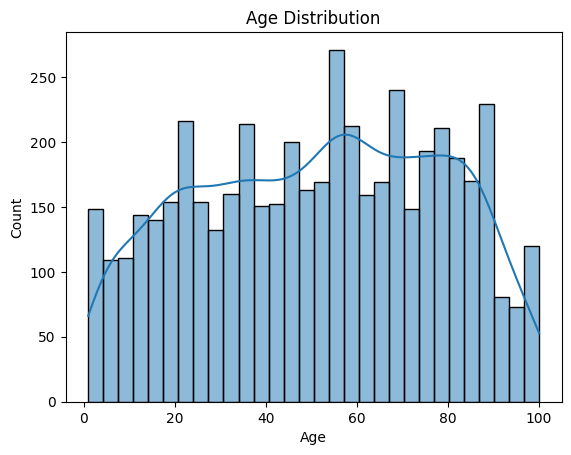

In [45]:
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.show()


4. Do certain diseases affect one gender more than the other?

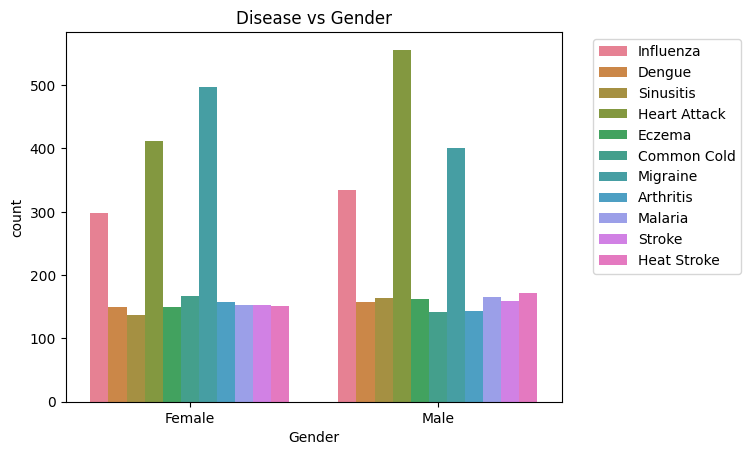

In [46]:
sns.countplot(data=df, x='Gender', hue='prognosis')
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Disease vs Gender')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

5. Are certain diseases more common in specific age groups?

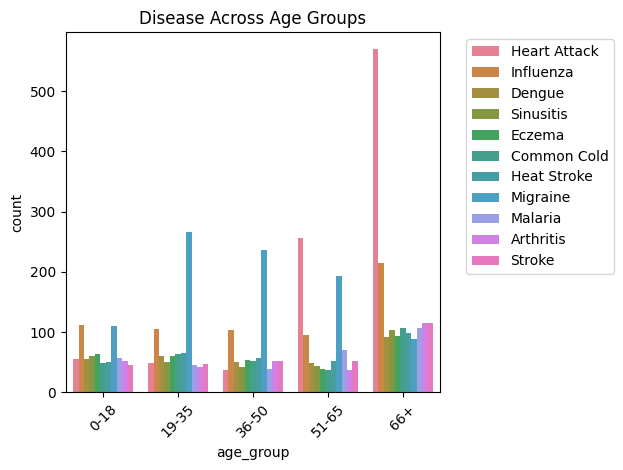

In [47]:
df['age_group'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-18','19-35','36-50','51-65','66+'])
sns.countplot(data=df, x='age_group', hue='prognosis')
plt.title('Disease Across Age Groups')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


6. What is the correlation between numerical features (e.g., Temp, Humidity)?

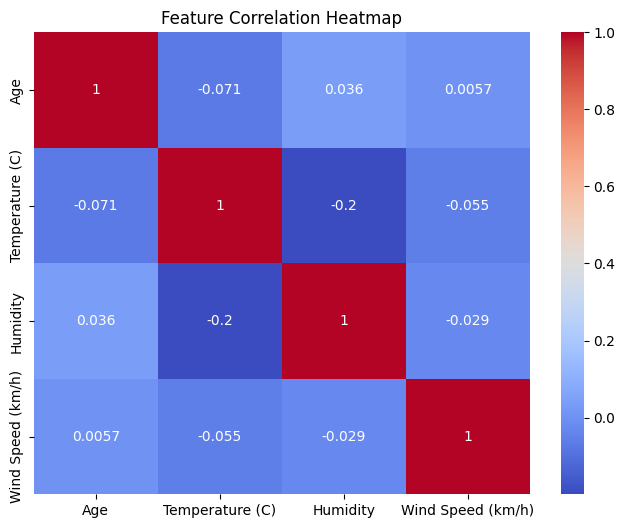

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Temperature (C)', 'Humidity', 'Wind Speed (km/h)']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


7. What’s the average temperature for each disease?

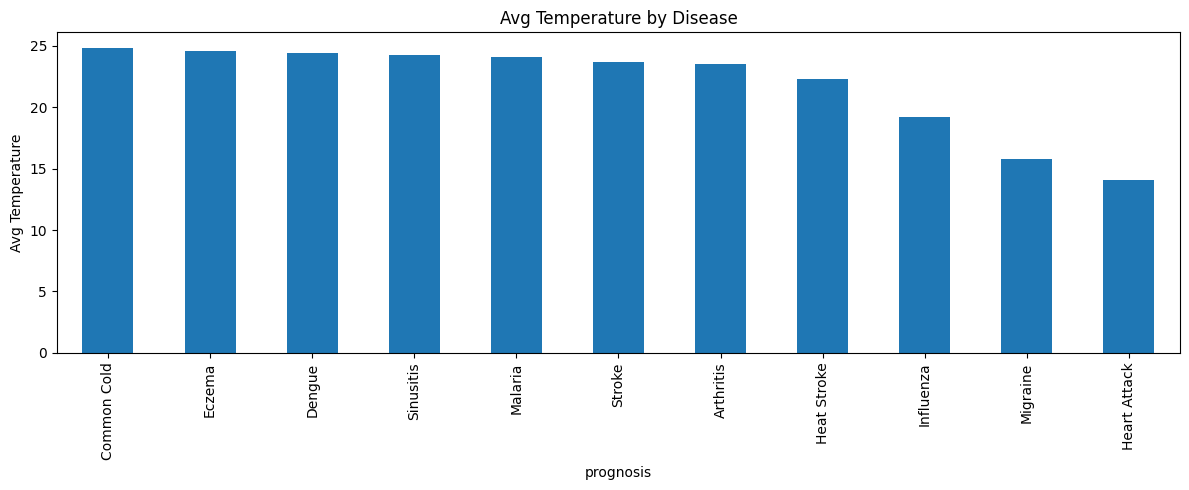

In [49]:
df.groupby('prognosis')['Temperature (C)'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.ylabel('Avg Temperature')
plt.title('Avg Temperature by Disease')
plt.tight_layout()
plt.show()


8. Which symptoms are most commonly associated with each disease?

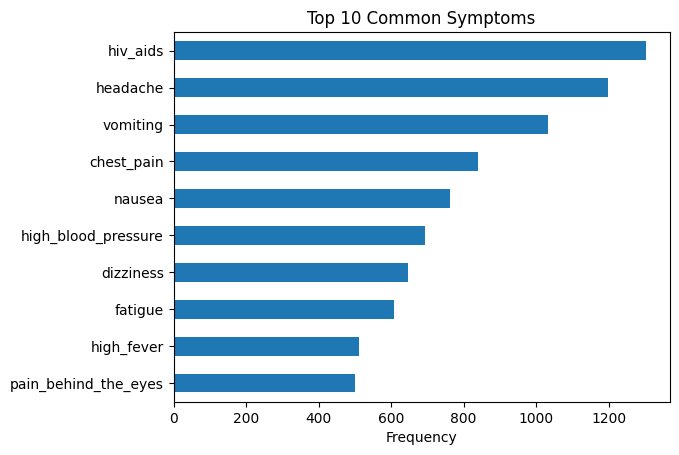

In [50]:
symptom_cols = [col for col in df.columns if col not in ['Age', 'Gender', 'Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'prognosis', 'age_group']]
symptom_frequency = df[symptom_cols].sum().sort_values(ascending=False)
symptom_frequency.head(10).plot(kind='barh')
plt.title('Top 10 Common Symptoms')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


9. Which disease is associated with the highest temperature or humidity?

In [51]:
df.groupby('prognosis')[['Temperature (C)', 'Humidity']].mean().sort_values(by='Temperature (C)', ascending=False).head()


,Temperature (C),Humidity
prognosis,,
Common Cold,24.861685,0.743836
Eczema,24.579731,0.744573
Dengue,24.440841,0.739144
Sinusitis,24.277118,0.738607
Malaria,24.066601,0.745359


10. Do males or females report more symptoms on average?

In [52]:
df['symptom_count'] = df[symptom_cols].sum(axis=1)
df.groupby('Gender')['symptom_count'].mean()


Gender
0    2.924536
1    2.955008
Name: symptom_count, dtype: float64

11. Does wind speed or humidity affect certain diseases more?

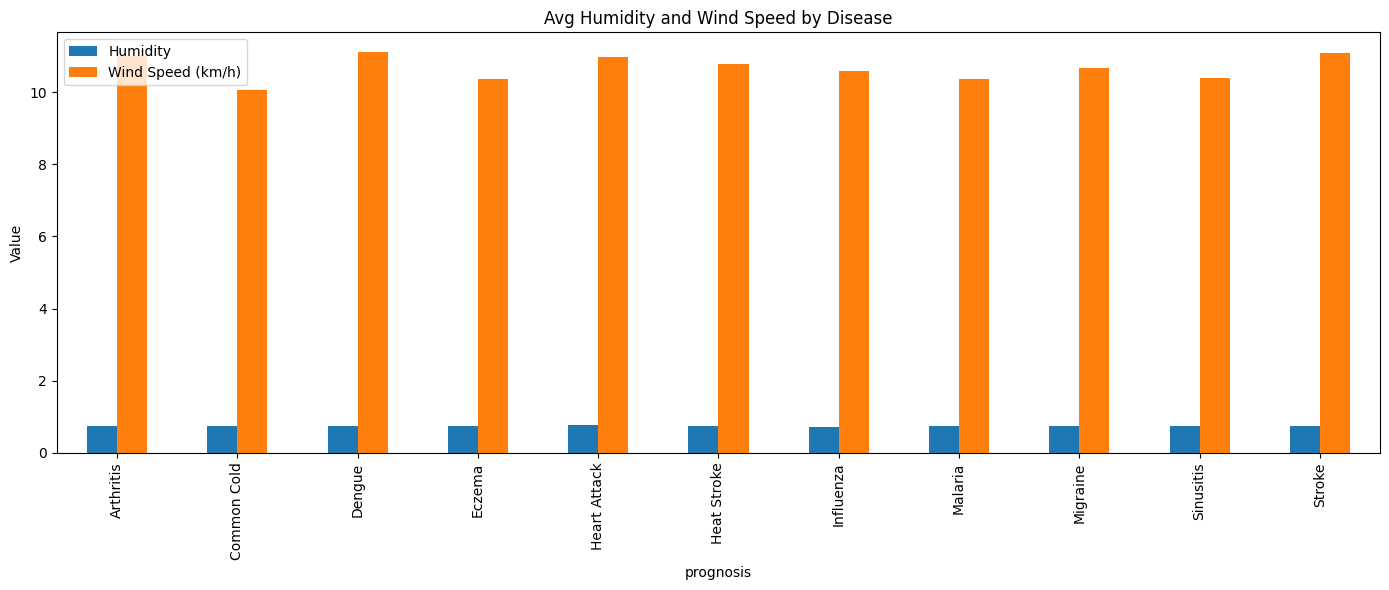

In [53]:
df.groupby('prognosis')[['Humidity', 'Wind Speed (km/h)']].mean().plot(kind='bar', figsize=(14, 6))
plt.title('Avg Humidity and Wind Speed by Disease')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


12. Which age group has the highest risk for specific diseases?

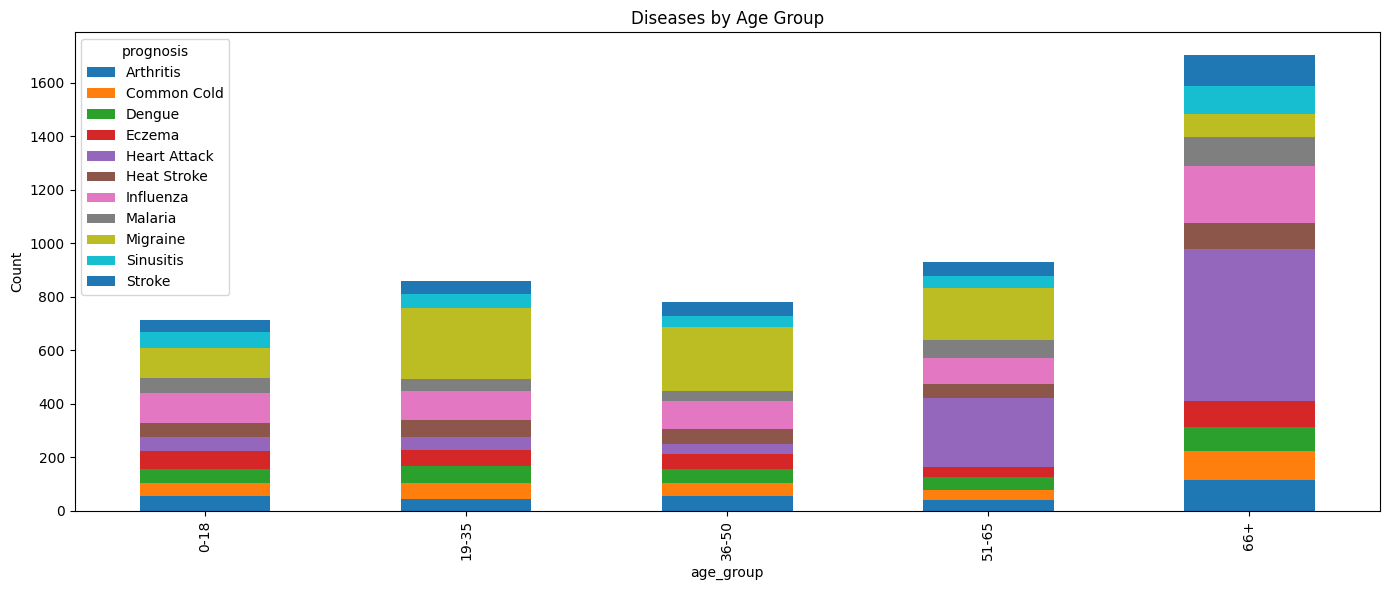

In [54]:
pd.crosstab(df['age_group'], df['prognosis']).plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Diseases by Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


13. How balanced is the target class (prognosis)?

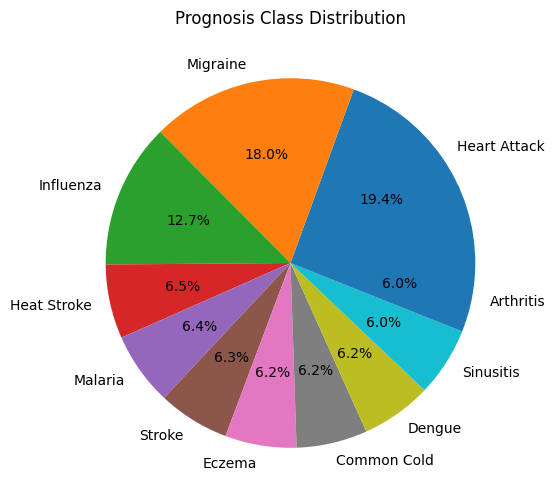

In [55]:
df['prognosis'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Prognosis Class Distribution')
plt.ylabel('')
plt.show()


✅ Suggestions
Label Encode the prognosis column for modeling.

Try tree-based models like Random Forest or XGBoost — they handle binary + numeric well.

Add dimensionality reduction (PCA) if needed to explore clustering or reduce feature space.

Feature importance analysis can reveal which symptoms are best predictors.

Use Streamlit or Gradio to build an interactive diagnosis app.

